In [61]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import xarray as xr
import os
# import pandas as pd
from glob import glob
#import climpredNEW.climpred 
#from climpredNEW.climpred.options import OPTIONS
from climpred.options import OPTIONS
import climpred
import pickle
from mpl_toolkits.basemap import Basemap
from numpy import meshgrid
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import itertools
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LatitudeLocator
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, TwoSlopeNorm
from scipy.stats import rankdata
import bottleneck as bn
import scipy.stats as stats
import re
import numpy as np

from function import preprocessUtils as putils
from function import masks
from function import verifications
from function import funs as f
from function import conf
from function import loadbias
from function import dataLoad

from function.taylorDiagram import TaylorDiagram
import numpy as NP
import matplotlib.pyplot as PLT


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
week_lead = 3 #[1,2,3,4]
day_num = (week_lead*7) -1
experiment_number = 'EX29' #for UNET experiment 

In [63]:

global dim_order, region_name, test_year, leads_
dim_order = conf.dim_order

test_year = 2019
leads_ = [6,13,20,27]

dir = '/glade/work/klesinger/FD_RZSM_deep_learning'
assert test_year == 2019, 'This is only the script for when the testing years are 2018-2019. Test year must = 2019.'


In [64]:
region_name = 'china' #['australia','china', 'CONUS']
obs_source = 'GLEAM' #['GLEAM','ERA5']

# assert region_name == 'CONUS' and obs_source =='ERA5' , 'We have not created an ERA5 model with GLEAM yet'
    

acc_value_directory = f'Data/ACC_dict_values/{region_name}' #This already has all of the ACC values computed seasonally

if obs_source == 'ERA5':
    soil_dir = conf.era_data
elif obs_source == 'GLEAM':
    soil_dir = conf.gleam_data

mask, mask_anom = masks.load_mask_vals(region_name)

In [65]:
global obs_anomaly,obs_raw
obs_anomaly,obs_raw = dataLoad.load_rzsm_observations(soil_dir, region_name)
obs_anomaly=obs_anomaly.sel(time = slice('2018-01-01','2020-02-15'))
obs_anomaly["time"] = obs_anomaly["time"].dt.floor("D")


gef_BC, ecm_BC = loadbias.load_additive_bias_anomaly(leads=leads_,region_name=region_name,obs_source=obs_source)
baseline_anomaly_ecmwf = verifications.load_ECMWF_baseline_anomaly(region_name)
baseline_anomaly_gefsv12= verifications.load_GEFSv12_baseline_anomaly(region_name)

Loading ECMWF baseline anomaly files
Loading GEFSv12 baseline anomaly files


In [66]:
'''We have the ACC values averaged over the region for each season, next we need to compute the standard deviation of each forecast'''
'''These are for the UNET experiments'''
acc_vals = dataLoad.open_ACC_pickle_season(acc_value_directory, region_name, obs_source, week_lead)

In [67]:
def compute_seasonal_climatological_spread(forecast,day_num):
    seasons = f.return_seasons()
    spread_by_season = {}

    for season, months in seasons.items():
        # Get init months
        init_months = forecast['init'].dt.month
        seasonal_forecast = forecast.sel(init=init_months.isin(months))

        # Standard deviation across members (spread)
        ensemble_spread = seasonal_forecast.std(dim='member')  # shape: (init, lead, lat, lon)

        # Climatological spread: average across inits
        climatological_spread = ensemble_spread.mean(dim='init').sel(lead=day_num).mean()
        climatological_spread = climatological_spread['RZSM'].values

        # Store in dictionary
        spread_by_season[season] = climatological_spread

    return spread_by_season

In [68]:
'''Get standard deviation of raw and bias corrected forecasts'''
print('Computing the standard deviation of the forecast')
gef_BC_std = compute_seasonal_climatological_spread(gef_BC,day_num)
ecm_BC_std = compute_seasonal_climatological_spread(ecm_BC,day_num)
ecmwf_raw_std = compute_seasonal_climatological_spread(verifications.rename_subx_for_climpred(baseline_anomaly_ecmwf),day_num)
gefsv12_raw_std = compute_seasonal_climatological_spread(verifications.rename_subx_for_climpred(baseline_anomaly_gefsv12),day_num)


Computing the standard deviation of the forecast


In [69]:


def filter_files_by_ex_GEFS(file_list, color_list, week_,obs_source):
    filtered_files = []
    
    for file in file_list:
        if obs_source== 'GLEAM':
            match = re.search(rf'Wk{week_}_testing_EX(\d+)_regular_RZSM', file)
        elif obs_source == 'ERA5':
            match = re.search(rf'Wk{week_}_testing_EX(\d+)_regular_ERA5_RZSM', file)
        if match:
            ex_value = f"EX{match.group(1)}"
            if ex_value in color_list:
                filtered_files.append(file)
    
    return filtered_files

def filter_files_by_ex_ECMWF(file_list, color_list, week_,obs_source):
    filtered_files = []
    
    for file in file_list:
        if obs_source =='GLEAM':
            match = re.search(rf'Wk{week_}_testing_EX(\d+)_ECMWF_regular_RZSM', file)
        elif obs_source == 'ERA5':
            match = re.search(rf'Wk{week_}_testing_EX(\d+)_ECMWF_regular_ERA5_RZSM', file)
        if match:
            ex_value = f"EX{match.group(1)}"
            if ex_value in color_list:
                filtered_files.append(file)
    
    return filtered_files

def filter_files_by_ex_GEFS_mean_squared_error(file_list, color_list, week_,obs_source):
    '''Currently only completed for CHINA'''
    filtered_files = []
    
    for file in file_list:
        if obs_source =='GLEAM':
            match = re.search(rf'Wk{week_}_testing_EX(\d+)_mse_RZSM', file)
        elif obs_source == 'ERA5':
            match = re.search(rf'Wk{week_}_testing_EX(\d+)_mse_ERA5_RZSM', file)
        if match:
            ex_value = f"EX{match.group(1)}"
            if ex_value in color_list:
                filtered_files.append(file)
    
    return filtered_files

def filter_files_by_ex_ECMWF_mean_squared_error(file_list, color_list, week_,obs_source):
    '''Currently only completed for CHINA'''
    filtered_files = []
    
    for file in file_list:
        if obs_source =='GLEAM':
            match = re.search(rf'Wk{week_}_testing_EX(\d+)_ECMWF_mse_RZSM', file)
        elif obs_source == 'ERA5':
            match = re.search(rf'Wk{week_}_testing_EX(\d+)_ECMWF_mse_ERA5_RZSM', file)
        if match:
            ex_value = f"EX{match.group(1)}"
            if ex_value in color_list:
                filtered_files.append(file)
    
    return filtered_files

In [70]:


def return_file_list_by_category(region_name, week_,obs_source):
    black = ['EX0','EX13']
    red = ['EX14','EX15','EX16','EX17','EX22','EX23','EX24','EX25']
    blue = ['EX1','EX2','EX3','EX4','EX5','EX6','EX7','EX8','EX9','EX10','EX11','EX12',
           'EX18','EX19','EX20','EX21','EX27','EX28','EX29']
    
    unet_files = sorted(glob(f'predictions/{region_name}/Wk{week_}_testing/*')) #With a specific subset of data
    #First find the correct experiments
    bias_correction_black_G = filter_files_by_ex_GEFS(unet_files, black, week_,obs_source)
    hybrid_blue_G = filter_files_by_ex_GEFS(unet_files, blue, week_,obs_source)
    obs_red_G = filter_files_by_ex_GEFS(unet_files, red, week_,obs_source)

    bias_correction_black_E = filter_files_by_ex_ECMWF(unet_files, black, week_,obs_source)
    hybrid_blue_E = filter_files_by_ex_ECMWF(unet_files, blue, week_,obs_source)
    obs_red_E = filter_files_by_ex_ECMWF(unet_files, red, week_,obs_source)
    
    return bias_correction_black_G, hybrid_blue_G, obs_red_G, bias_correction_black_E, hybrid_blue_E, obs_red_E

def return_file_list_by_category_with_MSE(region_name, week_,obs_source):
    black = ['EX0','EX13']
    red = ['EX14','EX15','EX16','EX17','EX22','EX23','EX24','EX25']
    blue = ['EX1','EX2','EX3','EX4','EX5','EX6','EX7','EX8','EX9','EX10','EX11','EX12',
           'EX18','EX19','EX20','EX21','EX27','EX28','EX29']
    
    unet_files = sorted(glob(f'predictions/{region_name}/Wk{week_}_testing/*')) #With a specific subset of data
    #First find the correct experiments
    bias_correction_black_G = filter_files_by_ex_GEFS(unet_files, black, week_,obs_source)
    hybrid_blue_G = filter_files_by_ex_GEFS(unet_files, blue, week_,obs_source)
    obs_red_G = filter_files_by_ex_GEFS(unet_files, red, week_,obs_source)

    bias_correction_black_E = filter_files_by_ex_ECMWF(unet_files, black, week_,obs_source)
    hybrid_blue_E = filter_files_by_ex_ECMWF(unet_files, blue, week_,obs_source)
    obs_red_E = filter_files_by_ex_ECMWF(unet_files, red, week_,obs_source)

    bias_correction_black_G_mse = filter_files_by_ex_GEFS_mean_squared_error(unet_files, black, week_,obs_source)
    hybrid_blue_G_mse = filter_files_by_ex_GEFS_mean_squared_error(unet_files, blue, week_,obs_source)
    obs_red_G_mse = filter_files_by_ex_GEFS_mean_squared_error(unet_files, red, week_,obs_source)
    
    bias_correction_black_E_mse = filter_files_by_ex_ECMWF_mean_squared_error(unet_files, black, week_,obs_source)
    hybrid_blue_E_mse = filter_files_by_ex_ECMWF_mean_squared_error(unet_files, blue, week_,obs_source)
    obs_red_E_mse = filter_files_by_ex_ECMWF_mean_squared_error(unet_files, red, week_,obs_source)
    
    return bias_correction_black_G, hybrid_blue_G, obs_red_G, bias_correction_black_E, hybrid_blue_E, obs_red_E, bias_correction_black_G_mse, hybrid_blue_G_mse, obs_red_G_mse, bias_correction_black_E_mse, hybrid_blue_E_mse, obs_red_E_mse


def create_empty_array(ecmwf_acc, day_num):
    u_acc = ecmwf_acc.sel(lead=day_num).copy(deep=True)
    u_crps = ecmwf_acc.sel(lead=day_num).copy(deep=True)
    u_acc[putils.xarray_varname(u_acc)][:,:] = 0
    u_crps[putils.xarray_varname(u_crps)][:,:] = 0
    return u_acc, u_crps

In [71]:
def get_UNET_std_forecast(region_name, obs_source, gef_BC, mask_anom,forecast_source,day_num,experiment_number=experiment_number):

    #test
    #experiment_number = 'EX29'

    ex29_gefs = []
    ex29_ecmwf = []
    for idx,week in enumerate([1,2,3,4]):
        #We only need a single week for this function to retrieve all data
        bias_correction_black_G, hybrid_blue_G, obs_red_G, bias_correction_black_E, hybrid_blue_E, obs_red_E  = return_file_list_by_category(region_name=region_name, week_=week,obs_source=obs_source)
        ex29_gefs.append([i for i in hybrid_blue_G if experiment_number in i][0])
        ex29_ecmwf.append([i for i in hybrid_blue_E if experiment_number in i][0])
        
    #Now we have all the weeks we need
    # create a merged forecast file

    if forecast_source == 'ECMWF':
        files = ex29_ecmwf
    else:
        files = ex29_gefs
        
    forecast = verifications.load_UNET_all_weeks(
        gefs=gef_BC, files=files, region_name=region_name,
        new_source=forecast_source, test_year=test_year,
        experiment_number=experiment_number,mask_anom = mask_anom)

    unet_std = compute_seasonal_climatological_spread(forecast,day_num)
    return unet_std

In [72]:
def get_UNET_std_forecast_MSE(region_name, obs_source, gef_BC, mask_anom,forecast_source,day_num,experiment_number, MSE_or_not):

    #test
    #experiment_number = 'EX29'

    ex29_gefs = []
    ex29_ecmwf = []
    ex29_gefs_mse = []
    ex29_ecmwf_mse = []
    for idx,week in enumerate([1,2,3,4]):
        #We only need a single week for this function to retrieve all data
        
        bias_correction_black_G, hybrid_blue_G, obs_red_G, bias_correction_black_E, hybrid_blue_E, obs_red_E, bias_correction_black_G_mse, hybrid_blue_G_mse, obs_red_G_mse, bias_correction_black_E_mse, hybrid_blue_E_mse, obs_red_E_mse  = return_file_list_by_category_with_MSE(region_name=region_name, week_=week,obs_source=obs_source)
        ex29_gefs.append([i for i in hybrid_blue_G if experiment_number in i][0])
        ex29_ecmwf.append([i for i in hybrid_blue_E if experiment_number in i][0])
        ex29_gefs_mse.append([i for i in hybrid_blue_G_mse if experiment_number in i][0])
        ex29_ecmwf_mse.append([i for i in hybrid_blue_E_mse if experiment_number in i][0])
    #Now we have all the weeks we need
    # create a merged forecast file

    if forecast_source == 'ECMWF':
        if MSE_or_not == 'mse':
            files = ex29_ecmwf_mse
        else:
            files = ex29_ecmwf
    else:
        if MSE_or_not == 'mse':
            files = ex29_gefs_mse
        else:
            files = ex29_gefs
        
    forecast = verifications.load_UNET_all_weeks(
        gefs=gef_BC, files=files, region_name=region_name,
        new_source=forecast_source, test_year=test_year,
        experiment_number=experiment_number,mask_anom = mask_anom)

    unet_std = compute_seasonal_climatological_spread(forecast,day_num)
    return unet_std

In [16]:
if region_name != 'china':
    unet_ecmwf_std = get_UNET_std_forecast(region_name, obs_source, gef_BC, mask_anom,'ECMWF',day_num,experiment_number=experiment_number)
    unet_gefsv12_std = get_UNET_std_forecast(region_name, obs_source, gef_BC, mask_anom,'GEFSv12',day_num,experiment_number=experiment_number)


Loading UNET testing predictions and reversing the min-max scaling to be back to anomalies
Day number is 6
(104, 11, 1, 48, 96)
Day number is 13
(104, 11, 1, 48, 96)
Day number is 20
(104, 11, 1, 48, 96)
Day number is 27
(104, 11, 1, 48, 96)
Loading UNET testing predictions and reversing the min-max scaling to be back to anomalies
Day number is 6
(104, 11, 1, 48, 96)
Day number is 13
(104, 11, 1, 48, 96)
Day number is 20
(104, 11, 1, 48, 96)
Day number is 27
(104, 11, 1, 48, 96)


In [21]:
def compute_obs_seasonal_std(obs_ds, varname='RZSM'):
    # Define seasons (matching your dict keys)
    seasons = f.return_seasons()

    stdrefs = {}

    for season_name, season_months in seasons.items():
        # Select data by month
        season_data = obs_ds.sel(time=obs_ds['time'].dt.month.isin(season_months))[varname]

        # Compute standard deviation over time, then mean over space
        std_per_pixel = season_data.std(dim='time')  # (lat, lon)
        mean_std = std_per_pixel.mean(dim=['latitude', 'longitude'])  # scalar

        # Store scalar value in dictionary
        stdrefs[season_name] = float(mean_std.values)

    return stdrefs

In [73]:
obs_std = compute_obs_seasonal_std(obs_anomaly, varname='RZSM')

In [139]:
#Use this function so that we can tweak the figures


class TaylorDiagram(object):
    """
    Taylor diagram.

    Plot model standard deviation and correlation to reference (data)
    sample in a single-quadrant polar plot, with r=stddev and
    theta=arccos(correlation).
    """

    def __init__(self, refstd,
                 fig=None, rect=111, label='_', srange=(0, 1.5), extend=False):
        """
        Set up Taylor diagram axes, i.e. single quadrant polar
        plot, using `mpl_toolkits.axisartist.floating_axes`.

        Parameters:

        * refstd: reference standard deviation to be compared to
        * fig: input Figure or None
        * rect: subplot definition
        * label: reference label
        * srange: stddev axis extension, in units of *refstd*
        * extend: extend diagram to negative correlations
        """

        from matplotlib.projections import PolarAxes
        import mpl_toolkits.axisartist.floating_axes as FA
        import mpl_toolkits.axisartist.grid_finder as GF

        self.refstd = refstd            # Reference standard deviation

        tr = PolarAxes.PolarTransform()

        # Correlation labels
        rlocs = NP.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1])
        if extend:
            # Diagram extended to negative correlations
            self.tmax = NP.pi
            rlocs = NP.concatenate((-rlocs[:0:-1], rlocs))
        else:
            # Diagram limited to positive correlations
            self.tmax = NP.pi/2
        tlocs = NP.arccos(rlocs)        # Conversion to polar angles
        gl1 = GF.FixedLocator(tlocs)    # Positions
        tf1 = GF.DictFormatter(dict(zip(tlocs, map(str, rlocs))))

        # Standard deviation axis extent (in units of reference stddev)
        self.smin = srange[0] * self.refstd
        self.smax = srange[1] * self.refstd

        ghelper = FA.GridHelperCurveLinear(
            tr,
            extremes=(0, self.tmax, self.smin, self.smax),
            grid_locator1=gl1, tick_formatter1=tf1)

        if fig is None:
            fig = PLT.figure()

        ax = FA.FloatingSubplot(fig, rect, grid_helper=ghelper)
        fig.add_subplot(ax)

        # Adjust axes
        ax.axis["top"].set_axis_direction("bottom")   # "Angle axis"
        ax.axis["top"].toggle(ticklabels=True, label=True)
        ax.axis["top"].major_ticklabels.set_axis_direction("top")
        ax.axis["top"].label.set_axis_direction("top")
        ax.axis["top"].label.set_text("Anomaly Correlation")

        ax.axis["left"].set_axis_direction("bottom")  # "X axis"
        ax.axis["left"].label.set_text("Standard deviation")

        ax.axis["right"].set_axis_direction("top")    # "Y-axis"
        ax.axis["right"].toggle(ticklabels=True)
        ax.axis["right"].major_ticklabels.set_axis_direction(
            "bottom" if extend else "left")

        if self.smin:
            ax.axis["bottom"].toggle(ticklabels=False, label=False)
        else:
            ax.axis["bottom"].set_visible(False)          # Unused

        self._ax = ax                   # Graphical axes
        self.ax = ax.get_aux_axes(tr)   # Polar coordinates

        # Add reference point and stddev contour
        l, = self.ax.plot([0], self.refstd, 'k*',
                          ls='', ms=10, label=label)
        t = NP.linspace(0, self.tmax)
        r = NP.zeros_like(t) + self.refstd
        self.ax.plot(t, r, 'k--', label='_')

        # Collect sample points for latter use (e.g. legend)
        self.samplePoints = [l]

    def add_sample(self, stddev, corrcoef, *args, **kwargs):
        """
        Add sample (*stddev*, *corrcoeff*) to the Taylor
        diagram. *args* and *kwargs* are directly propagated to the
        `Figure.plot` command.
        """

        l, = self.ax.plot(NP.arccos(corrcoef), stddev,
                          *args, **kwargs)  # (theta, radius)
        self.samplePoints.append(l)

        return l

    def add_grid(self, *args, **kwargs):
        """Add a grid."""

        self._ax.grid(*args, **kwargs)

    def add_contours(self, levels=5, **kwargs):
        """
        Add constant centered RMS difference contours, defined by *levels*.
        """

        rs, ts = NP.meshgrid(NP.linspace(self.smin, self.smax),
                             NP.linspace(0, self.tmax))
        # Compute centered RMS difference
        rms = NP.sqrt(self.refstd**2 + rs**2 - 2*self.refstd*rs*NP.cos(ts))

        contours = self.ax.contour(ts, rs, rms, levels, **kwargs)

        return contours

    def add_correlation_lines(self, correlations=None, **kwargs):
        """Draw radial lines (spokes) from origin to each correlation level."""
        if correlations is None:
            correlations = [0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1]
        for r in correlations:
            theta = np.arccos(r)
            self.ax.plot([theta, theta], [self.smin, self.smax], **kwargs)

# Data

In [74]:

# Reference std
stdrefs = dict(DJF=obs_std['DJF'],
               MAM=obs_std['MAM'],
               JJA=obs_std['JJA'],
               SON=obs_std['SON'])


# Sample std,rho: Be sure to check order and that correct numbers are placed!
samples = dict(
    DJF=[[gefsv12_raw_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_GEFS_MEM_baseline_RZSM_ACC'], "GEFSv12-raw"],
            [gef_BC_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_GEFS_MEM_BC_baseline_RZSM_ACC'], "GEFSv12-BC"],
            [ecmwf_raw_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_ECMWF_MEM_baseline_RZSM_ACC'], "ECMWF-raw"],
            [ecm_BC_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_ECMWF_MEM_BC_baseline_RZSM_ACC'], "ECMWF-BC"],
            [unet_gefsv12_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_{experiment_number}_MEM_RZSM_ACC'], "DL-DM_G"],
            [unet_ecmwf_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_ACC'], "DL-DM_E"]],
    
    MAM=[[gefsv12_raw_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_GEFS_MEM_baseline_RZSM_ACC'], "GEFSv12-raw"],
            [gef_BC_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_GEFS_MEM_BC_baseline_RZSM_ACC'], "GEFSv12-BC"],
            [ecmwf_raw_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_ECMWF_MEM_baseline_RZSM_ACC'], "ECMWF-raw"],
            [ecm_BC_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_ECMWF_MEM_BC_baseline_RZSM_ACC'], "ECMWF-BC"],
            [unet_gefsv12_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_{experiment_number}_MEM_RZSM_ACC'], "DL-DM_G"],
            [unet_ecmwf_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_ACC'], "DL-DM_E"]],
    
    JJA=[[gefsv12_raw_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_GEFS_MEM_baseline_RZSM_ACC'], "GEFSv12-raw"],
            [gef_BC_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_GEFS_MEM_BC_baseline_RZSM_ACC'], "GEFSv12-BC"],
            [ecmwf_raw_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_ECMWF_MEM_baseline_RZSM_ACC'], "ECMWF-raw"],
            [ecm_BC_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_ECMWF_MEM_BC_baseline_RZSM_ACC'], "ECMWF-BC"],
            [unet_gefsv12_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_{experiment_number}_MEM_RZSM_ACC'], "DL-DM_G"],
            [unet_ecmwf_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_ACC'], "DL-DM_E"]],
    
    SON=[[gefsv12_raw_std['SON'], acc_vals[f'SON_Wk{week_lead}_GEFS_MEM_baseline_RZSM_ACC'], "GEFSv12-raw"],
            [gef_BC_std['SON'], acc_vals[f'SON_Wk{week_lead}_GEFS_MEM_BC_baseline_RZSM_ACC'], "GEFSv12-BC"],
            [ecmwf_raw_std['SON'], acc_vals[f'SON_Wk{week_lead}_ECMWF_MEM_baseline_RZSM_ACC'], "ECMWF-raw"],
            [ecm_BC_std['SON'], acc_vals[f'SON_Wk{week_lead}_ECMWF_MEM_BC_baseline_RZSM_ACC'], "ECMWF-BC"],
            [unet_gefsv12_std['SON'], acc_vals[f'SON_Wk{week_lead}_{experiment_number}_MEM_RZSM_ACC'], "DL-DM_G"],
            [unet_ecmwf_std['SON'], acc_vals[f'SON_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_ACC'], "DL-DM_E"]]
        )

# This is only setup for **australia**. With china we can soon add the MSE value results

In [46]:

class TaylorDiagram_AUS(object):
    """
    Taylor diagram.

    Plot model standard deviation and correlation to reference (data)
    sample in a single-quadrant polar plot, with r=stddev and
    theta=arccos(correlation).
    """

    def __init__(self, refstd,
                 fig=None, rect=111, label='_', srange=(0, 1.5), extend=False):
        """
        Set up Taylor diagram axes, i.e. single quadrant polar
        plot, using `mpl_toolkits.axisartist.floating_axes`.

        Parameters:

        * refstd: reference standard deviation to be compared to
        * fig: input Figure or None
        * rect: subplot definition
        * label: reference label
        * srange: stddev axis extension, in units of *refstd*
        * extend: extend diagram to negative correlations
        """

        from matplotlib.projections import PolarAxes
        import mpl_toolkits.axisartist.floating_axes as FA
        import mpl_toolkits.axisartist.grid_finder as GF

        self.refstd = refstd            # Reference standard deviation

        tr = PolarAxes.PolarTransform()

        # Correlation labels
        rlocs = NP.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1])
        if extend:
            # Diagram extended to negative correlations
            self.tmax = NP.pi
            rlocs = NP.concatenate((-rlocs[:0:-1], rlocs))
        else:
            # Diagram limited to positive correlations
            self.tmax = NP.pi/2
        tlocs = NP.arccos(rlocs)        # Conversion to polar angles
        gl1 = GF.FixedLocator(tlocs)    # Positions
        tf1 = GF.DictFormatter(dict(zip(tlocs, map(str, rlocs))))

        # Standard deviation axis extent (in units of reference stddev)
        self.smin = srange[0] * self.refstd
        self.smax = srange[1] * self.refstd

        ghelper = FA.GridHelperCurveLinear(
            tr,
            extremes=(0, self.tmax, self.smin, self.smax),
            grid_locator1=gl1, tick_formatter1=tf1)

        if fig is None:
            fig = PLT.figure()

        ax = FA.FloatingSubplot(fig, rect, grid_helper=ghelper)
        fig.add_subplot(ax)

        # Adjust axes
        ax.axis["top"].set_axis_direction("bottom")   # "Angle axis"
        ax.axis["top"].toggle(ticklabels=True, label=True)
        ax.axis["top"].major_ticklabels.set_axis_direction("top")
        ax.axis["top"].label.set_axis_direction("top")
        ax.axis["top"].label.set_text("Anomaly Correlation")

        ax.axis["left"].set_axis_direction("bottom")  # "X axis"
        ax.axis["left"].label.set_text("Standard deviation")

        ax.axis["right"].set_axis_direction("top")    # "Y-axis"
        ax.axis["right"].toggle(ticklabels=True)
        ax.axis["right"].major_ticklabels.set_axis_direction(
            "bottom" if extend else "left")

        if self.smin:
            ax.axis["bottom"].toggle(ticklabels=False, label=False)
        else:
            ax.axis["bottom"].set_visible(False)          # Unused

        self._ax = ax                   # Graphical axes
        self.ax = ax.get_aux_axes(tr)   # Polar coordinates

        # Add reference point and stddev contour
        l, = self.ax.plot([0], self.refstd, 'k*',
                          ls='', ms=10, label=label)
        t = NP.linspace(0, self.tmax)
        r = NP.zeros_like(t) + self.refstd
        self.ax.plot(t, r, 'k--', label='_')

        # Collect sample points for latter use (e.g. legend)
        self.samplePoints = [l]

    def add_sample(self, stddev, corrcoef, *args, **kwargs):
        """
        Add sample (*stddev*, *corrcoeff*) to the Taylor
        diagram. *args* and *kwargs* are directly propagated to the
        `Figure.plot` command.
        """

        l, = self.ax.plot(NP.arccos(corrcoef), stddev,
                          *args, **kwargs)  # (theta, radius)
        self.samplePoints.append(l)

        return l

    def add_grid(self, *args, **kwargs):
        """Add a grid."""

        self._ax.grid(*args, **kwargs)

    def add_contours(self, levels=5, **kwargs):
        """
        Add constant centered RMS difference contours, defined by *levels*.
        """

        rs, ts = NP.meshgrid(NP.linspace(self.smin, self.smax),
                             NP.linspace(0, self.tmax))
        # Compute centered RMS difference
        rms = NP.sqrt(self.refstd**2 + rs**2 - 2*self.refstd*rs*NP.cos(ts))

        contours = self.ax.contour(ts, rs, rms, levels, **kwargs)

        return contours

    def add_correlation_lines(self, correlations=None, **kwargs):
        """Draw radial lines (spokes) from origin to each correlation level."""
        if correlations is None:
            correlations = [0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1]
        for r in correlations:
            theta = np.arccos(r)
            self.ax.plot([theta, theta], [self.smin, self.smax], **kwargs)


In [54]:
#!/usr/bin/env python

__version__ = "Time-stamp: <2018-12-06 11:55:22 ycopin>"
__author__ = "Yannick Copin <yannick.copin@laposte.net>"

"""
Example of use of TaylorDiagram. Illustration dataset courtesy of Michael
Rawlins.

Rawlins, M. A., R. S. Bradley, H. F. Diaz, 2012. Assessment of regional climate
model simulation estimates over the Northeast United States, Journal of
Geophysical Research (2012JGRD..11723112R).
"""


#Use this function so that we can tweak the figures




#############################################################################################################################################################################################################################################################################################################
#############################################################################################################################################################################################################################################################################################################
#############################################################################################################################################################################################################################################################################################################
#############################################################################################################################################################################################################################################################################################################
#############################################################################################################################################################################################################################################################################################################

if region_name == 'australia':
    # Colormap (see http://www.scipy.org/Cookbook/Matplotlib/Show_colormaps)
    colors = PLT.matplotlib.cm.Set1(NP.linspace(0,1,len(samples['DJF'])))
    
    
    rects = dict(DJF=221,
                 MAM=222,
                 JJA=223,
                 SON=224)
    
    fig = PLT.figure(figsize=(16, 12),dpi=300)
    
    fig.suptitle(f"{region_name} RZSM Anomaly Taylor Diagram\nObs source: {obs_source}\nWeek lead {week_lead}", size='x-large', y=.97)
    
    for season in ['DJF','MAM','JJA','SON']:
        std_models = [i[0] for i in samples[season]]
        max_std = np.nanmax(std_models)
        srange = (0, max_std / stdrefs[season] + 0.1)  # add a small buffer
        
        dia = TaylorDiagram_AUS(stdrefs[season], fig=fig, rect=rects[season],
                            label='Reference', srange=srange,)
    
        # dia.ax.plot(x95,y95,color='k')
        # dia.ax.plot(x99,y99,color='k')
    
        # Add samples to Taylor diagram
        for i,(stddev,corrcoef,name) in enumerate(samples[season]):
            color = colors[i]
            if i == 3:
                color = 'saddlebrown'  # or 'brown', '#8B4513', etc.
            elif i == 5:
                color = 'green'
            dia.add_sample(stddev, corrcoef,
                           marker='$%d$' % (i+1), ms=16, ls='',
                           #mfc='k', mec='k', # B&W
                           mfc=color, mec=color, # Colors
                           label=name)
    
        # Add RMS contours, and label them
        contours = dia.add_contours(levels=5, colors='0.5') # 5 levels
        dia.ax.clabel(contours, inline=1, fontsize=13, fmt='%.3f')
        # Tricky: ax is the polar ax (used for plots), _ax is the
        # container (used for layout)
        dia._ax.set_title(season,fontweight='bold')
        dia.add_correlation_lines(linestyle='--', color='gray', linewidth=0.8)
    
    
    # Add a figure legend and title. For loc option, place x,y tuple inside [ ].
    # Can also use special options here:
    # http://matplotlib.sourceforge.net/users/legend_guide.html
    
    fig.legend(dia.samplePoints,
               [p.get_label() for p in dia.samplePoints],
               numpoints=1,
               prop={'size': 12},       # Increase font size
               loc='center',
               labelspacing=1.2,        # Vertical spacing between labels
               borderpad=1.2,           # Padding inside the legend box
               handletextpad=1.2,       # Space between marker and text
               columnspacing=1.5)       # Space between columns (if used)
    
    
    fig.tight_layout(pad=2.5)
    
    save_dir = f'Outputs/taylor_diagram'
    os.makedirs(save_dir,exist_ok=True)
    
    PLT.savefig(f'{save_dir}/{region_name}_{obs_source}_week{week_lead}.png')
    PLT.show()


# CONUS

In [59]:
#!/usr/bin/env python

#Use this function so that we can tweak the figures


class TaylorDiagram(object):
    """
    Taylor diagram.

    Plot model standard deviation and correlation to reference (data)
    sample in a single-quadrant polar plot, with r=stddev and
    theta=arccos(correlation).
    """

    def __init__(self, refstd,
                 fig=None, rect=111, label='_', srange=(0, 1.5), extend=False):
        """
        Set up Taylor diagram axes, i.e. single quadrant polar
        plot, using `mpl_toolkits.axisartist.floating_axes`.

        Parameters:

        * refstd: reference standard deviation to be compared to
        * fig: input Figure or None
        * rect: subplot definition
        * label: reference label
        * srange: stddev axis extension, in units of *refstd*
        * extend: extend diagram to negative correlations
        """

        from matplotlib.projections import PolarAxes
        import mpl_toolkits.axisartist.floating_axes as FA
        import mpl_toolkits.axisartist.grid_finder as GF

        self.refstd = refstd            # Reference standard deviation

        tr = PolarAxes.PolarTransform()

        # Correlation labels
        rlocs = NP.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1])
        if extend:
            # Diagram extended to negative correlations
            self.tmax = NP.pi
            rlocs = NP.concatenate((-rlocs[:0:-1], rlocs))
        else:
            # Diagram limited to positive correlations
            self.tmax = NP.pi/2
        tlocs = NP.arccos(rlocs)        # Conversion to polar angles
        gl1 = GF.FixedLocator(tlocs)    # Positions
        tf1 = GF.DictFormatter(dict(zip(tlocs, map(str, rlocs))))

        # Standard deviation axis extent (in units of reference stddev)
        self.smin = srange[0] * self.refstd
        self.smax = srange[1] * self.refstd

        ghelper = FA.GridHelperCurveLinear(
            tr,extremes=(0, self.tmax, self.smin, self.smax),
            grid_locator1=gl1, tick_formatter1=tf1)


        if fig is None:
            fig = PLT.figure()

        ax = FA.FloatingSubplot(fig, rect, grid_helper=ghelper)
        fig.add_subplot(ax)

        # Adjust axes
        ax.axis["top"].set_axis_direction("bottom")   # "Angle axis"
        ax.axis["top"].toggle(ticklabels=True, label=True)
        ax.axis["top"].major_ticklabels.set_axis_direction("top")
        ax.axis["top"].label.set_axis_direction("top")
        ax.axis["top"].label.set_text("Anomaly Correlation")

        ax.axis["left"].set_axis_direction("bottom")  # "X axis"
        ax.axis["left"].label.set_text("Standard deviation")

        ax.axis["right"].set_axis_direction("top")    # "Y-axis"
        ax.axis["right"].toggle(ticklabels=True)
        ax.axis["right"].major_ticklabels.set_axis_direction(
            "bottom" if extend else "left")

        if self.smin:
            ax.axis["bottom"].toggle(ticklabels=False, label=False)
        else:
            ax.axis["bottom"].set_visible(False)          # Unused

        self._ax = ax                   # Graphical axes
        self.ax = ax.get_aux_axes(tr)   # Polar coordinates

        # Add reference point and stddev contour
        l, = self.ax.plot([0], self.refstd, 'k*',
                          ls='', ms=10, label=label)
        t = NP.linspace(0, self.tmax)
        r = NP.zeros_like(t) + self.refstd
        self.ax.plot(t, r, 'k--', label='_')

        # Collect sample points for latter use (e.g. legend)
        self.samplePoints = [l]

    def add_sample(self, stddev, corrcoef, *args, **kwargs):
        """
        Add sample (*stddev*, *corrcoeff*) to the Taylor
        diagram. *args* and *kwargs* are directly propagated to the
        `Figure.plot` command.
        """

        l, = self.ax.plot(NP.arccos(corrcoef), stddev,
                          *args, **kwargs)  # (theta, radius)
        self.samplePoints.append(l)

        return l

    def add_grid(self, *args, **kwargs):
        """Add a grid."""

        self._ax.grid(*args, **kwargs)

    def add_contours(self, levels=5, **kwargs):
        """
        Add constant centered RMS difference contours, defined by *levels*.
        """

        rs, ts = NP.meshgrid(NP.linspace(self.smin, self.smax),
                             NP.linspace(0, self.tmax))
        # Compute centered RMS difference
        rms = NP.sqrt(self.refstd**2 + rs**2 - 2*self.refstd*rs*NP.cos(ts))

        contours = self.ax.contour(ts, rs, rms, levels, **kwargs)

        return contours

    def add_correlation_lines(self, correlations=None, **kwargs):
        """Draw radial lines (spokes) from origin to each correlation level."""
        if correlations is None:
            correlations = [0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1]
        for r in correlations:
            theta = np.arccos(r)
            self.ax.plot([theta, theta], [self.smin, self.smax], **kwargs)


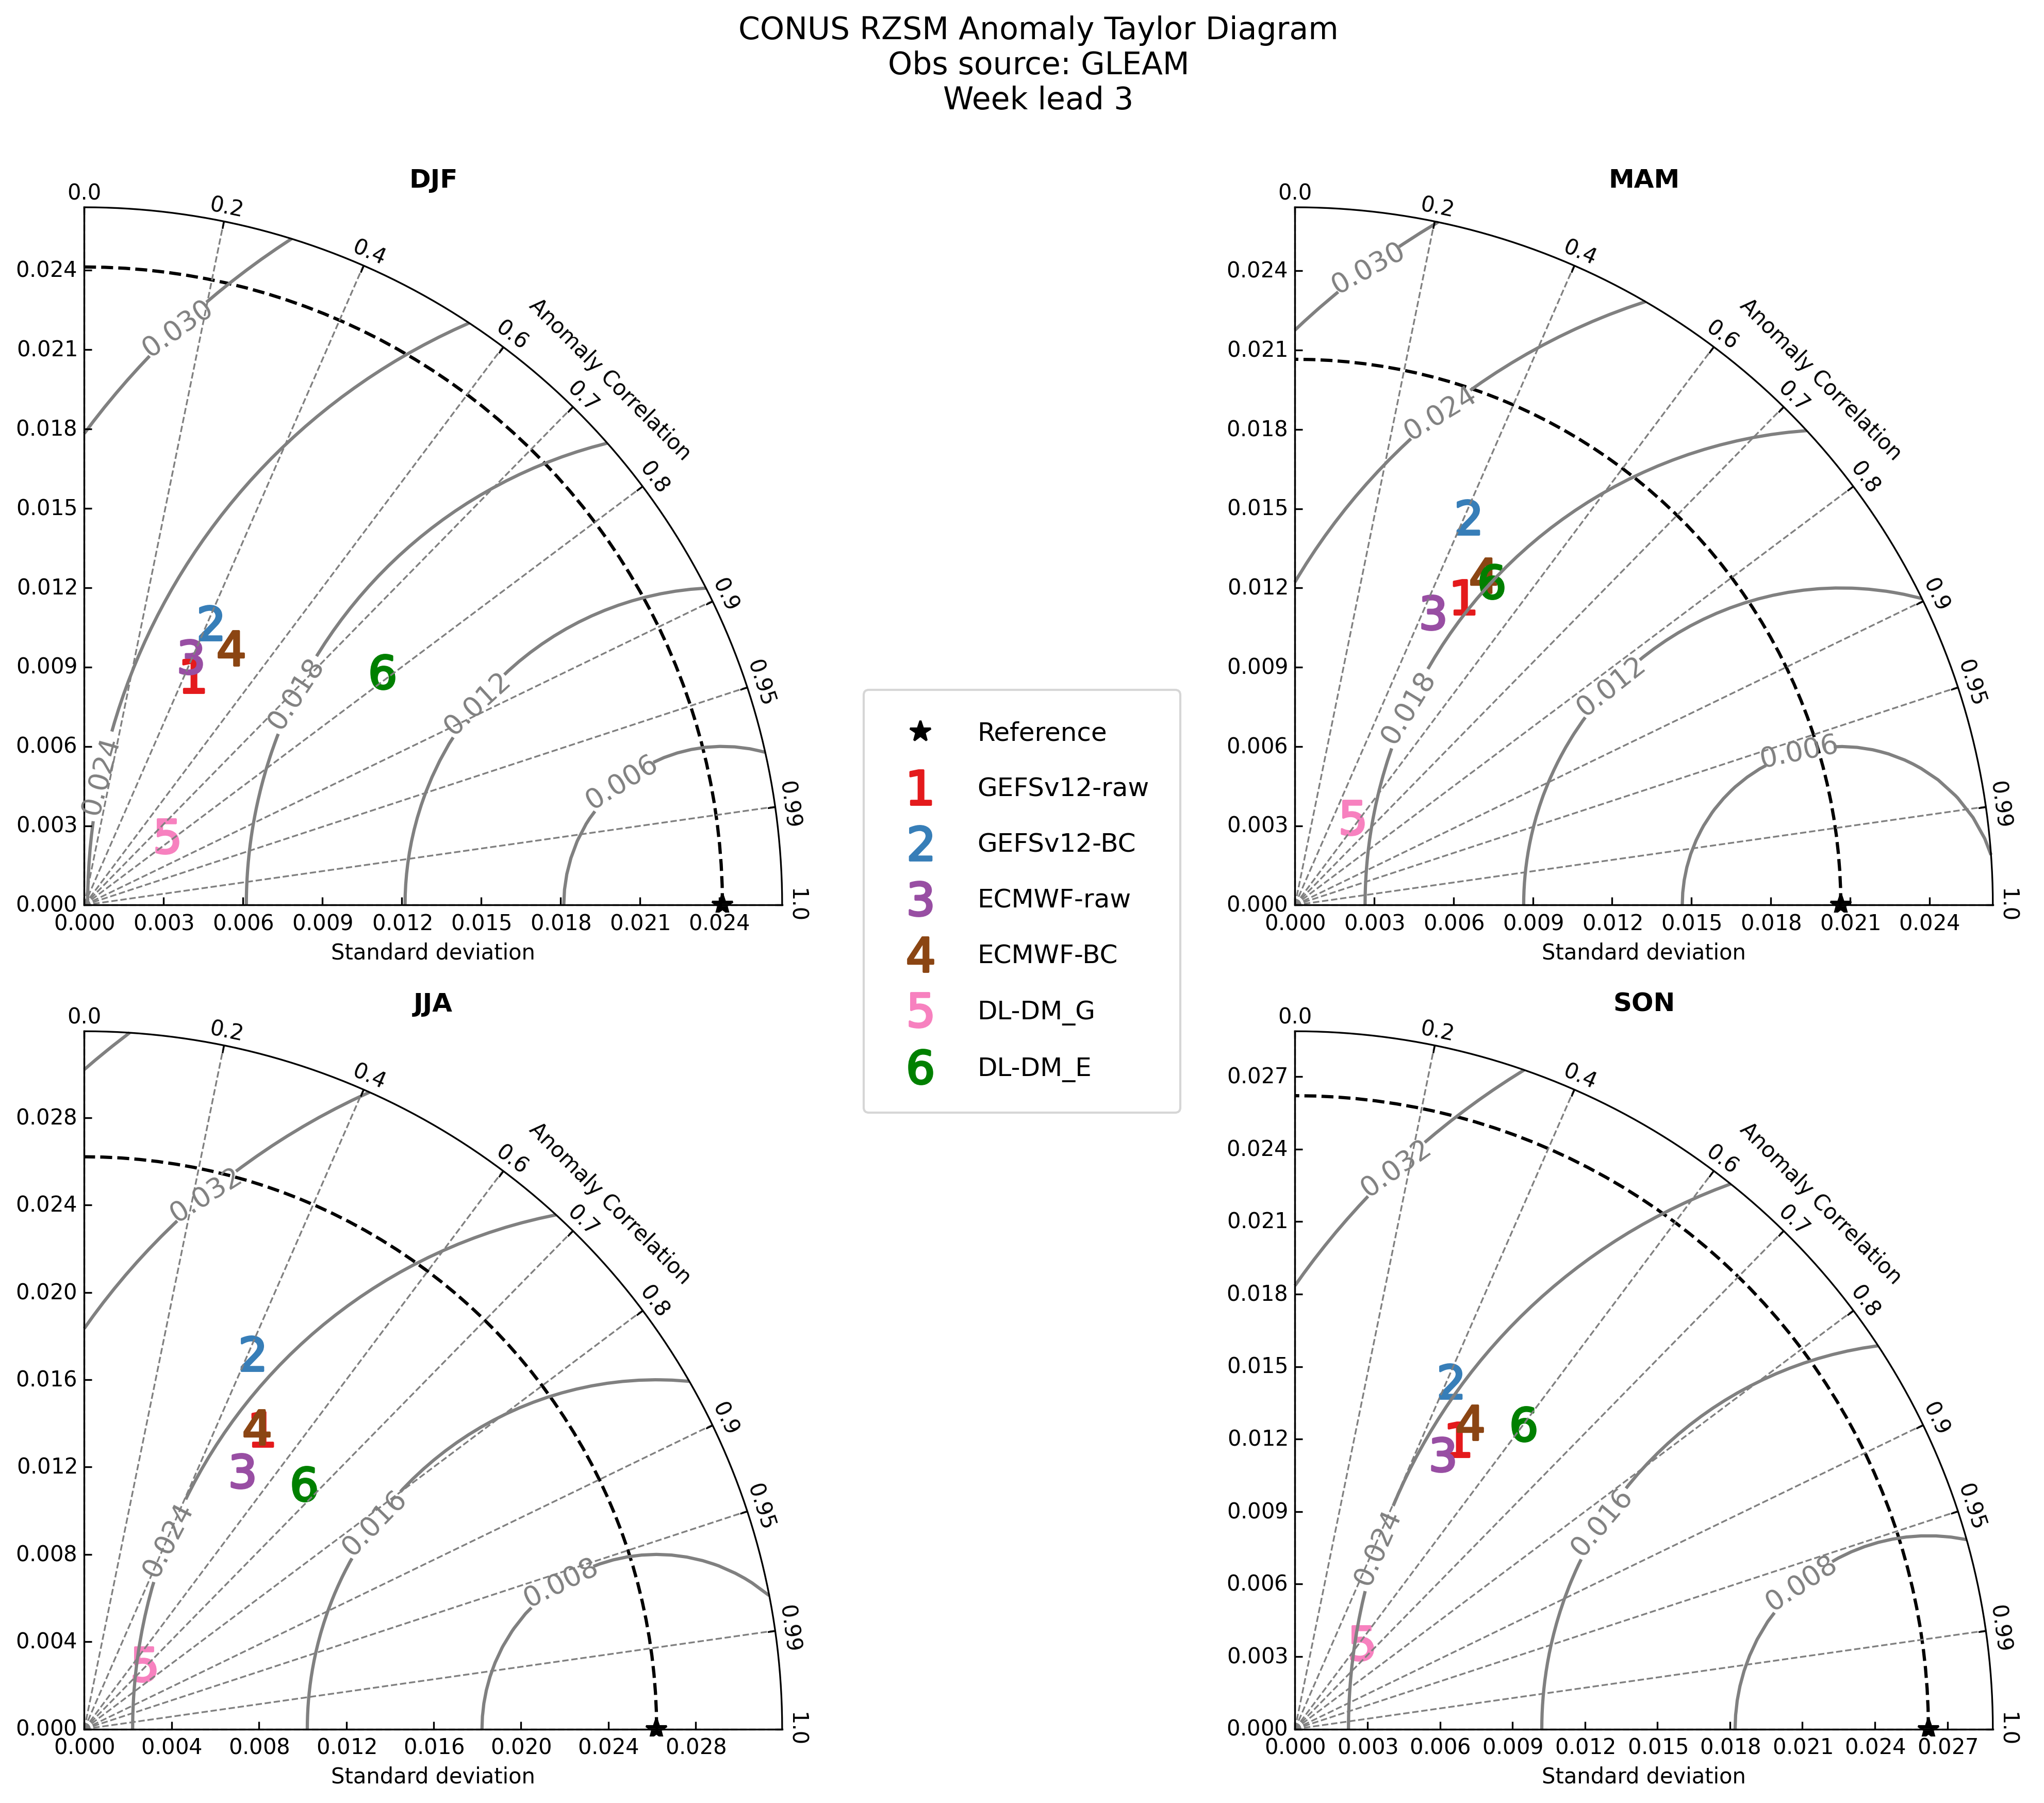

In [60]:



#############################################################################################################################################################################################################################################################################################################
#############################################################################################################################################################################################################################################################################################################
#############################################################################################################################################################################################################################################################################################################
#############################################################################################################################################################################################################################################################################################################
#############################################################################################################################################################################################################################################################################################################

if region_name == 'CONUS':
    # Colormap (see http://www.scipy.org/Cookbook/Matplotlib/Show_colormaps)
    colors = PLT.matplotlib.cm.Set1(NP.linspace(0,1,len(samples['DJF'])))
    
    
    rects = dict(DJF=221,
                 MAM=222,
                 JJA=223,
                 SON=224)
    
    fig = PLT.figure(figsize=(16, 12),dpi=300)
    
    fig.suptitle(f"{region_name} RZSM Anomaly Taylor Diagram\nObs source: {obs_source}\nWeek lead {week_lead}", size='x-large', y=.97)
    
    for season in ['DJF','MAM','JJA','SON']:
        std_models = [i[0] for i in samples[season]]
        max_std = np.nanmax(std_models)
        srange = (0, max_std / stdrefs[season] + 0.5)  # add a small buffer
        
        dia = TaylorDiagram(stdrefs[season], fig=fig, rect=rects[season],
                            label='Reference', srange=srange,)
    
        # dia.ax.plot(x95,y95,color='k')
        # dia.ax.plot(x99,y99,color='k')
    
        # Add samples to Taylor diagram
        for i,(stddev,corrcoef,name) in enumerate(samples[season]):
            color = colors[i]
            if i == 3:
                color = 'saddlebrown'  # or 'brown', '#8B4513', etc.
            elif i == 5:
                color = 'green'
            dia.add_sample(stddev, corrcoef,
                           marker='$%d$' % (i+1), ms=16, ls='',
                           #mfc='k', mec='k', # B&W
                           mfc=color, mec=color, # Colors
                           label=name)
    
        # Add RMS contours, and label them
        contours = dia.add_contours(levels=5, colors='0.5') # 5 levels
        dia.ax.clabel(contours, inline=1, fontsize=13, fmt='%.3f')
        # Tricky: ax is the polar ax (used for plots), _ax is the
        # container (used for layout)
        dia._ax.set_title(season,fontweight='bold')
        dia.add_correlation_lines(linestyle='--', color='gray', linewidth=0.8)
    
    
    # Add a figure legend and title. For loc option, place x,y tuple inside [ ].
    # Can also use special options here:
    # http://matplotlib.sourceforge.net/users/legend_guide.html
    
    fig.legend(dia.samplePoints,
               [p.get_label() for p in dia.samplePoints],
               numpoints=1,
               prop={'size': 12},       # Increase font size
               loc='center',
               labelspacing=1.2,        # Vertical spacing between labels
               borderpad=1.2,           # Padding inside the legend box
               handletextpad=1.2,       # Space between marker and text
               columnspacing=1.5)       # Space between columns (if used)
    
    
    fig.tight_layout(pad=2.5)
    
    save_dir = f'Outputs/taylor_diagram'
    os.makedirs(save_dir,exist_ok=True)
    
    PLT.savefig(f'{save_dir}/{region_name}_{obs_source}_week{week_lead}.png')
    PLT.show()


## Make china plots with MSE

In [79]:
mse=True

print(f'Working on {region_name} and including mean squared error results')
unet_ecmwf_std = get_UNET_std_forecast_MSE(region_name, obs_source, gef_BC, mask_anom,'ECMWF',day_num,experiment_number=experiment_number, MSE_or_not='mse')
unet_gefsv12_std = get_UNET_std_forecast_MSE(region_name, obs_source, gef_BC, mask_anom,'GEFSv12',day_num,experiment_number=experiment_number,MSE_or_not='mse')
unet_ecmwf_mse_std = get_UNET_std_forecast_MSE(region_name, obs_source, gef_BC, mask_anom,'ECMWF',day_num,experiment_number=experiment_number,MSE_or_not='no')
unet_gefsv12_mse_std = get_UNET_std_forecast_MSE(region_name, obs_source, gef_BC, mask_anom,'GEFSv12',day_num,experiment_number=experiment_number,MSE_or_not='no')

#!/usr/bin/env python

__version__ = "Time-stamp: <2018-12-06 11:55:22 ycopin>"
__author__ = "Yannick Copin <yannick.copin@laposte.net>"

"""
Example of use of TaylorDiagram. Illustration dataset courtesy of Michael
Rawlins.

Rawlins, M. A., R. S. Bradley, H. F. Diaz, 2012. Assessment of regional climate
model simulation estimates over the Northeast United States, Journal of
Geophysical Research (2012JGRD..11723112R).
"""

if region_name == 'china':
    # Reference std
    stdrefs = dict(DJF=obs_std['DJF'],
                   MAM=obs_std['MAM'],
                   JJA=obs_std['JJA'],
                   SON=obs_std['SON'])
    
    
    # Sample std,rho: Be sure to check order and that correct numbers are placed!
    samples = dict(
        DJF=[[gefsv12_raw_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_GEFS_MEM_baseline_RZSM_ACC'], "GEFSv12-raw"],
                [gef_BC_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_GEFS_MEM_BC_baseline_RZSM_ACC'], "GEFSv12-BC"],
                [ecmwf_raw_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_ECMWF_MEM_baseline_RZSM_ACC'], "ECMWF-raw"],
                [ecm_BC_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_ECMWF_MEM_BC_baseline_RZSM_ACC'], "ECMWF-BC"],
                [unet_gefsv12_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_{experiment_number}_MEM_RZSM_ACC'], "DL-DM-G[crps]"],
                [unet_ecmwf_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_ACC'], "DL-DM-E[crps]"],
                [unet_gefsv12_mse_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_{experiment_number}_MEM_RZSM_mse_ACC'], "DL-DM-G[mse]"],
                [unet_ecmwf_mse_std['DJF'], acc_vals[f'DJF_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_mse_ACC'], "DL-DM-E[mse]"]],
        
        MAM=[[gefsv12_raw_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_GEFS_MEM_baseline_RZSM_ACC'], "GEFSv12-raw"],
                [gef_BC_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_GEFS_MEM_BC_baseline_RZSM_ACC'], "GEFSv12-BC"],
                [ecmwf_raw_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_ECMWF_MEM_baseline_RZSM_ACC'], "ECMWF-raw"],
                [ecm_BC_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_ECMWF_MEM_BC_baseline_RZSM_ACC'], "ECMWF-BC"],
                [unet_gefsv12_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_{experiment_number}_MEM_RZSM_ACC'], "DL-DM-G[crps]"],
                [unet_ecmwf_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_ACC'], "DL-DM-E[crps]"],
                [unet_gefsv12_mse_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_{experiment_number}_MEM_RZSM_mse_ACC'], "DL-DM-G[mse]"],
                [unet_ecmwf_mse_std['MAM'], acc_vals[f'MAM_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_mse_ACC'], "DL-DM-E[mse]"]],
        
        JJA=[[gefsv12_raw_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_GEFS_MEM_baseline_RZSM_ACC'], "GEFSv12-raw"],
                [gef_BC_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_GEFS_MEM_BC_baseline_RZSM_ACC'], "GEFSv12-BC"],
                [ecmwf_raw_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_ECMWF_MEM_baseline_RZSM_ACC'], "ECMWF-raw"],
                [ecm_BC_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_ECMWF_MEM_BC_baseline_RZSM_ACC'], "ECMWF-BC"],
                [unet_gefsv12_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_{experiment_number}_MEM_RZSM_ACC'], "DL-DM-G[crps]"],
                [unet_ecmwf_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_ACC'], "DL-DM-E[crps]"],
                [unet_gefsv12_mse_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_{experiment_number}_MEM_RZSM_mse_ACC'], "DL-DM-G[mse]"],
                [unet_ecmwf_mse_std['JJA'], acc_vals[f'JJA_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_mse_ACC'], "DL-DM-E[mse]"]],
        
        SON=[[gefsv12_raw_std['SON'], acc_vals[f'SON_Wk{week_lead}_GEFS_MEM_baseline_RZSM_ACC'], "GEFSv12-raw"],
                [gef_BC_std['SON'], acc_vals[f'SON_Wk{week_lead}_GEFS_MEM_BC_baseline_RZSM_ACC'], "GEFSv12-BC"],
                [ecmwf_raw_std['SON'], acc_vals[f'SON_Wk{week_lead}_ECMWF_MEM_baseline_RZSM_ACC'], "ECMWF-raw"],
                [ecm_BC_std['SON'], acc_vals[f'SON_Wk{week_lead}_ECMWF_MEM_BC_baseline_RZSM_ACC'], "ECMWF-BC"],
                [unet_gefsv12_std['SON'], acc_vals[f'SON_Wk{week_lead}_{experiment_number}_MEM_RZSM_ACC'], "DL-DM-G[crps]"],
                [unet_ecmwf_std['SON'], acc_vals[f'SON_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_ACC'], "DL-DM-E[crps]"],
                [unet_gefsv12_mse_std['SON'], acc_vals[f'SON_Wk{week_lead}_{experiment_number}_MEM_RZSM_mse_ACC'], "DL-DM-G[mse]"],
                [unet_ecmwf_mse_std['SON'], acc_vals[f'SON_Wk{week_lead}_{experiment_number}_ECMWF_MEM_RZSM_mse_ACC'], "DL-DM-E[mse]"]]
    )



    # Colormap (see http://www.scipy.org/Cookbook/Matplotlib/Show_colormaps)
    colors = PLT.matplotlib.cm.Set1(NP.linspace(0,1,len(samples['DJF'])))
    
    
    rects = dict(DJF=221,
                 MAM=222,
                 JJA=223,
                 SON=224)
    
    fig = PLT.figure(figsize=(16, 12),dpi=300)
    
    fig.suptitle(f"{region_name} RZSM Anomaly Taylor Diagram\nObs source: {obs_source}\nWeek lead {week_lead}", size='x-large', y=.97)
    
    for season in ['DJF','MAM','JJA','SON']:
        std_models = [i[0] for i in samples[season]]
        max_std = np.nanmax(std_models)
        srange = (0, max_std / stdrefs[season] + 0.2)  # add a small buffer
        
        dia = TaylorDiagram(stdrefs[season], fig=fig, rect=rects[season],
                            label='Reference', srange=srange,)
    
        # dia.ax.plot(x95,y95,color='k')
        # dia.ax.plot(x99,y99,color='k')
    
        # Add samples to Taylor diagram
        for i,(stddev,corrcoef,name) in enumerate(samples[season]):
            color = colors[i]
            if i == 3:
                color = 'saddlebrown'  # or 'brown', '#8B4513', etc.
            elif i == 4:
                color = 'orange'
            elif i == 5:
                color = 'purple'
            dia.add_sample(stddev, corrcoef,
                           marker='$%d$' % (i+1), ms=16, ls='',
                           #mfc='k', mec='k', # B&W
                           mfc=color, mec=color, # Colors
                           label=name)
    
        # Add RMS contours, and label them
        contours = dia.add_contours(levels=5, colors='0.5') # 5 levels
        dia.ax.clabel(contours, inline=1, fontsize=13, fmt='%.3f')
        # Tricky: ax is the polar ax (used for plots), _ax is the
        # container (used for layout)
        dia._ax.set_title(season,fontweight='bold')
        dia.add_correlation_lines(linestyle='--', color='gray', linewidth=0.8)
    
    
    # Add a figure legend and title. For loc option, place x,y tuple inside [ ].
    # Can also use special options here:
    # http://matplotlib.sourceforge.net/users/legend_guide.html
    
    fig.legend(dia.samplePoints,
               [p.get_label() for p in dia.samplePoints],
               numpoints=1,
               prop={'size': 12},       # Increase font size
               loc='center',
               labelspacing=1.2,        # Vertical spacing between labels
               borderpad=1.2,           # Padding inside the legend box
               handletextpad=1.2,       # Space between marker and text
               columnspacing=1.5)       # Space between columns (if used)
    
    
    fig.tight_layout(pad=2.5)
    
    save_dir = f'Outputs/taylor_diagram'
    os.makedirs(save_dir,exist_ok=True)
    
    PLT.savefig(f'{save_dir}/{region_name}_{obs_source}_week{week_lead}_with_MSE.png')
    PLT.show()


NameError: name 'unet_gefsv12_mse_std' is not defined

# China no MSE

In [76]:
class TaylorDiagram(object):
    """
    Taylor diagram.

    Plot model standard deviation and correlation to reference (data)
    sample in a single-quadrant polar plot, with r=stddev and
    theta=arccos(correlation).
    """

    def __init__(self, refstd,
                 fig=None, rect=111, label='_', srange=(0, 1.5), extend=False):
        """
        Set up Taylor diagram axes, i.e. single quadrant polar
        plot, using `mpl_toolkits.axisartist.floating_axes`.

        Parameters:

        * refstd: reference standard deviation to be compared to
        * fig: input Figure or None
        * rect: subplot definition
        * label: reference label
        * srange: stddev axis extension, in units of *refstd*
        * extend: extend diagram to negative correlations
        """

        from matplotlib.projections import PolarAxes
        import mpl_toolkits.axisartist.floating_axes as FA
        import mpl_toolkits.axisartist.grid_finder as GF

        self.refstd = refstd            # Reference standard deviation

        tr = PolarAxes.PolarTransform()

        # Correlation labels
        rlocs = NP.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1])
        if extend:
            # Diagram extended to negative correlations
            self.tmax = NP.pi
            rlocs = NP.concatenate((-rlocs[:0:-1], rlocs))
        else:
            # Diagram limited to positive correlations
            self.tmax = NP.pi/2
        tlocs = NP.arccos(rlocs)        # Conversion to polar angles
        gl1 = GF.FixedLocator(tlocs)    # Positions
        tf1 = GF.DictFormatter(dict(zip(tlocs, map(str, rlocs))))

        # Standard deviation axis extent (in units of reference stddev)
        self.smin = srange[0] * self.refstd
        self.smax = srange[1] * self.refstd

        ghelper = FA.GridHelperCurveLinear(
            tr,
            extremes=(0, self.tmax, self.smin, self.smax),
            grid_locator1=gl1, tick_formatter1=tf1)

        if fig is None:
            fig = PLT.figure()

        ax = FA.FloatingSubplot(fig, rect, grid_helper=ghelper)
        fig.add_subplot(ax)

        # Adjust axes
        ax.axis["top"].set_axis_direction("bottom")   # "Angle axis"
        ax.axis["top"].toggle(ticklabels=True, label=True)
        ax.axis["top"].major_ticklabels.set_axis_direction("top")
        ax.axis["top"].label.set_axis_direction("top")
        ax.axis["top"].label.set_text("Anomaly Correlation")

        ax.axis["left"].set_axis_direction("bottom")  # "X axis"
        ax.axis["left"].label.set_text("Standard deviation")

        ax.axis["right"].set_axis_direction("top")    # "Y-axis"
        ax.axis["right"].toggle(ticklabels=True)
        ax.axis["right"].major_ticklabels.set_axis_direction(
            "bottom" if extend else "left")

        if self.smin:
            ax.axis["bottom"].toggle(ticklabels=False, label=False)
        else:
            ax.axis["bottom"].set_visible(False)          # Unused

        self._ax = ax                   # Graphical axes
        self.ax = ax.get_aux_axes(tr)   # Polar coordinates

        # Add reference point and stddev contour
        l, = self.ax.plot([0], self.refstd, 'k*',
                          ls='', ms=10, label=label)
        t = NP.linspace(0, self.tmax)
        r = NP.zeros_like(t) + self.refstd
        self.ax.plot(t, r, 'k--', label='_')

        # Collect sample points for latter use (e.g. legend)
        self.samplePoints = [l]

    def add_sample(self, stddev, corrcoef, *args, **kwargs):
        """
        Add sample (*stddev*, *corrcoeff*) to the Taylor
        diagram. *args* and *kwargs* are directly propagated to the
        `Figure.plot` command.
        """

        l, = self.ax.plot(NP.arccos(corrcoef), stddev,
                          *args, **kwargs)  # (theta, radius)
        self.samplePoints.append(l)

        return l

    def add_grid(self, *args, **kwargs):
        """Add a grid."""

        self._ax.grid(*args, **kwargs)

    def add_contours(self, levels=5, **kwargs):
        """
        Add constant centered RMS difference contours, defined by *levels*.
        """

        rs, ts = NP.meshgrid(NP.linspace(self.smin, self.smax),
                             NP.linspace(0, self.tmax))
        # Compute centered RMS difference
        rms = NP.sqrt(self.refstd**2 + rs**2 - 2*self.refstd*rs*NP.cos(ts))

        contours = self.ax.contour(ts, rs, rms, levels, **kwargs)

        return contours

    def add_correlation_lines(self, correlations=None, **kwargs):
        """Draw radial lines (spokes) from origin to each correlation level."""
        if correlations is None:
            correlations = [0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1]
        for r in correlations:
            theta = np.arccos(r)
            self.ax.plot([theta, theta], [self.smin, self.smax], **kwargs)


Loading UNET testing predictions and reversing the min-max scaling to be back to anomalies
Day number is 6
(104, 11, 1, 48, 96)
Day number is 13
(104, 11, 1, 48, 96)
Day number is 20
(104, 11, 1, 48, 96)
Day number is 27
(104, 11, 1, 48, 96)
Loading UNET testing predictions and reversing the min-max scaling to be back to anomalies
Day number is 6
(104, 11, 1, 48, 96)
Day number is 13
(104, 11, 1, 48, 96)
Day number is 20
(104, 11, 1, 48, 96)
Day number is 27
(104, 11, 1, 48, 96)


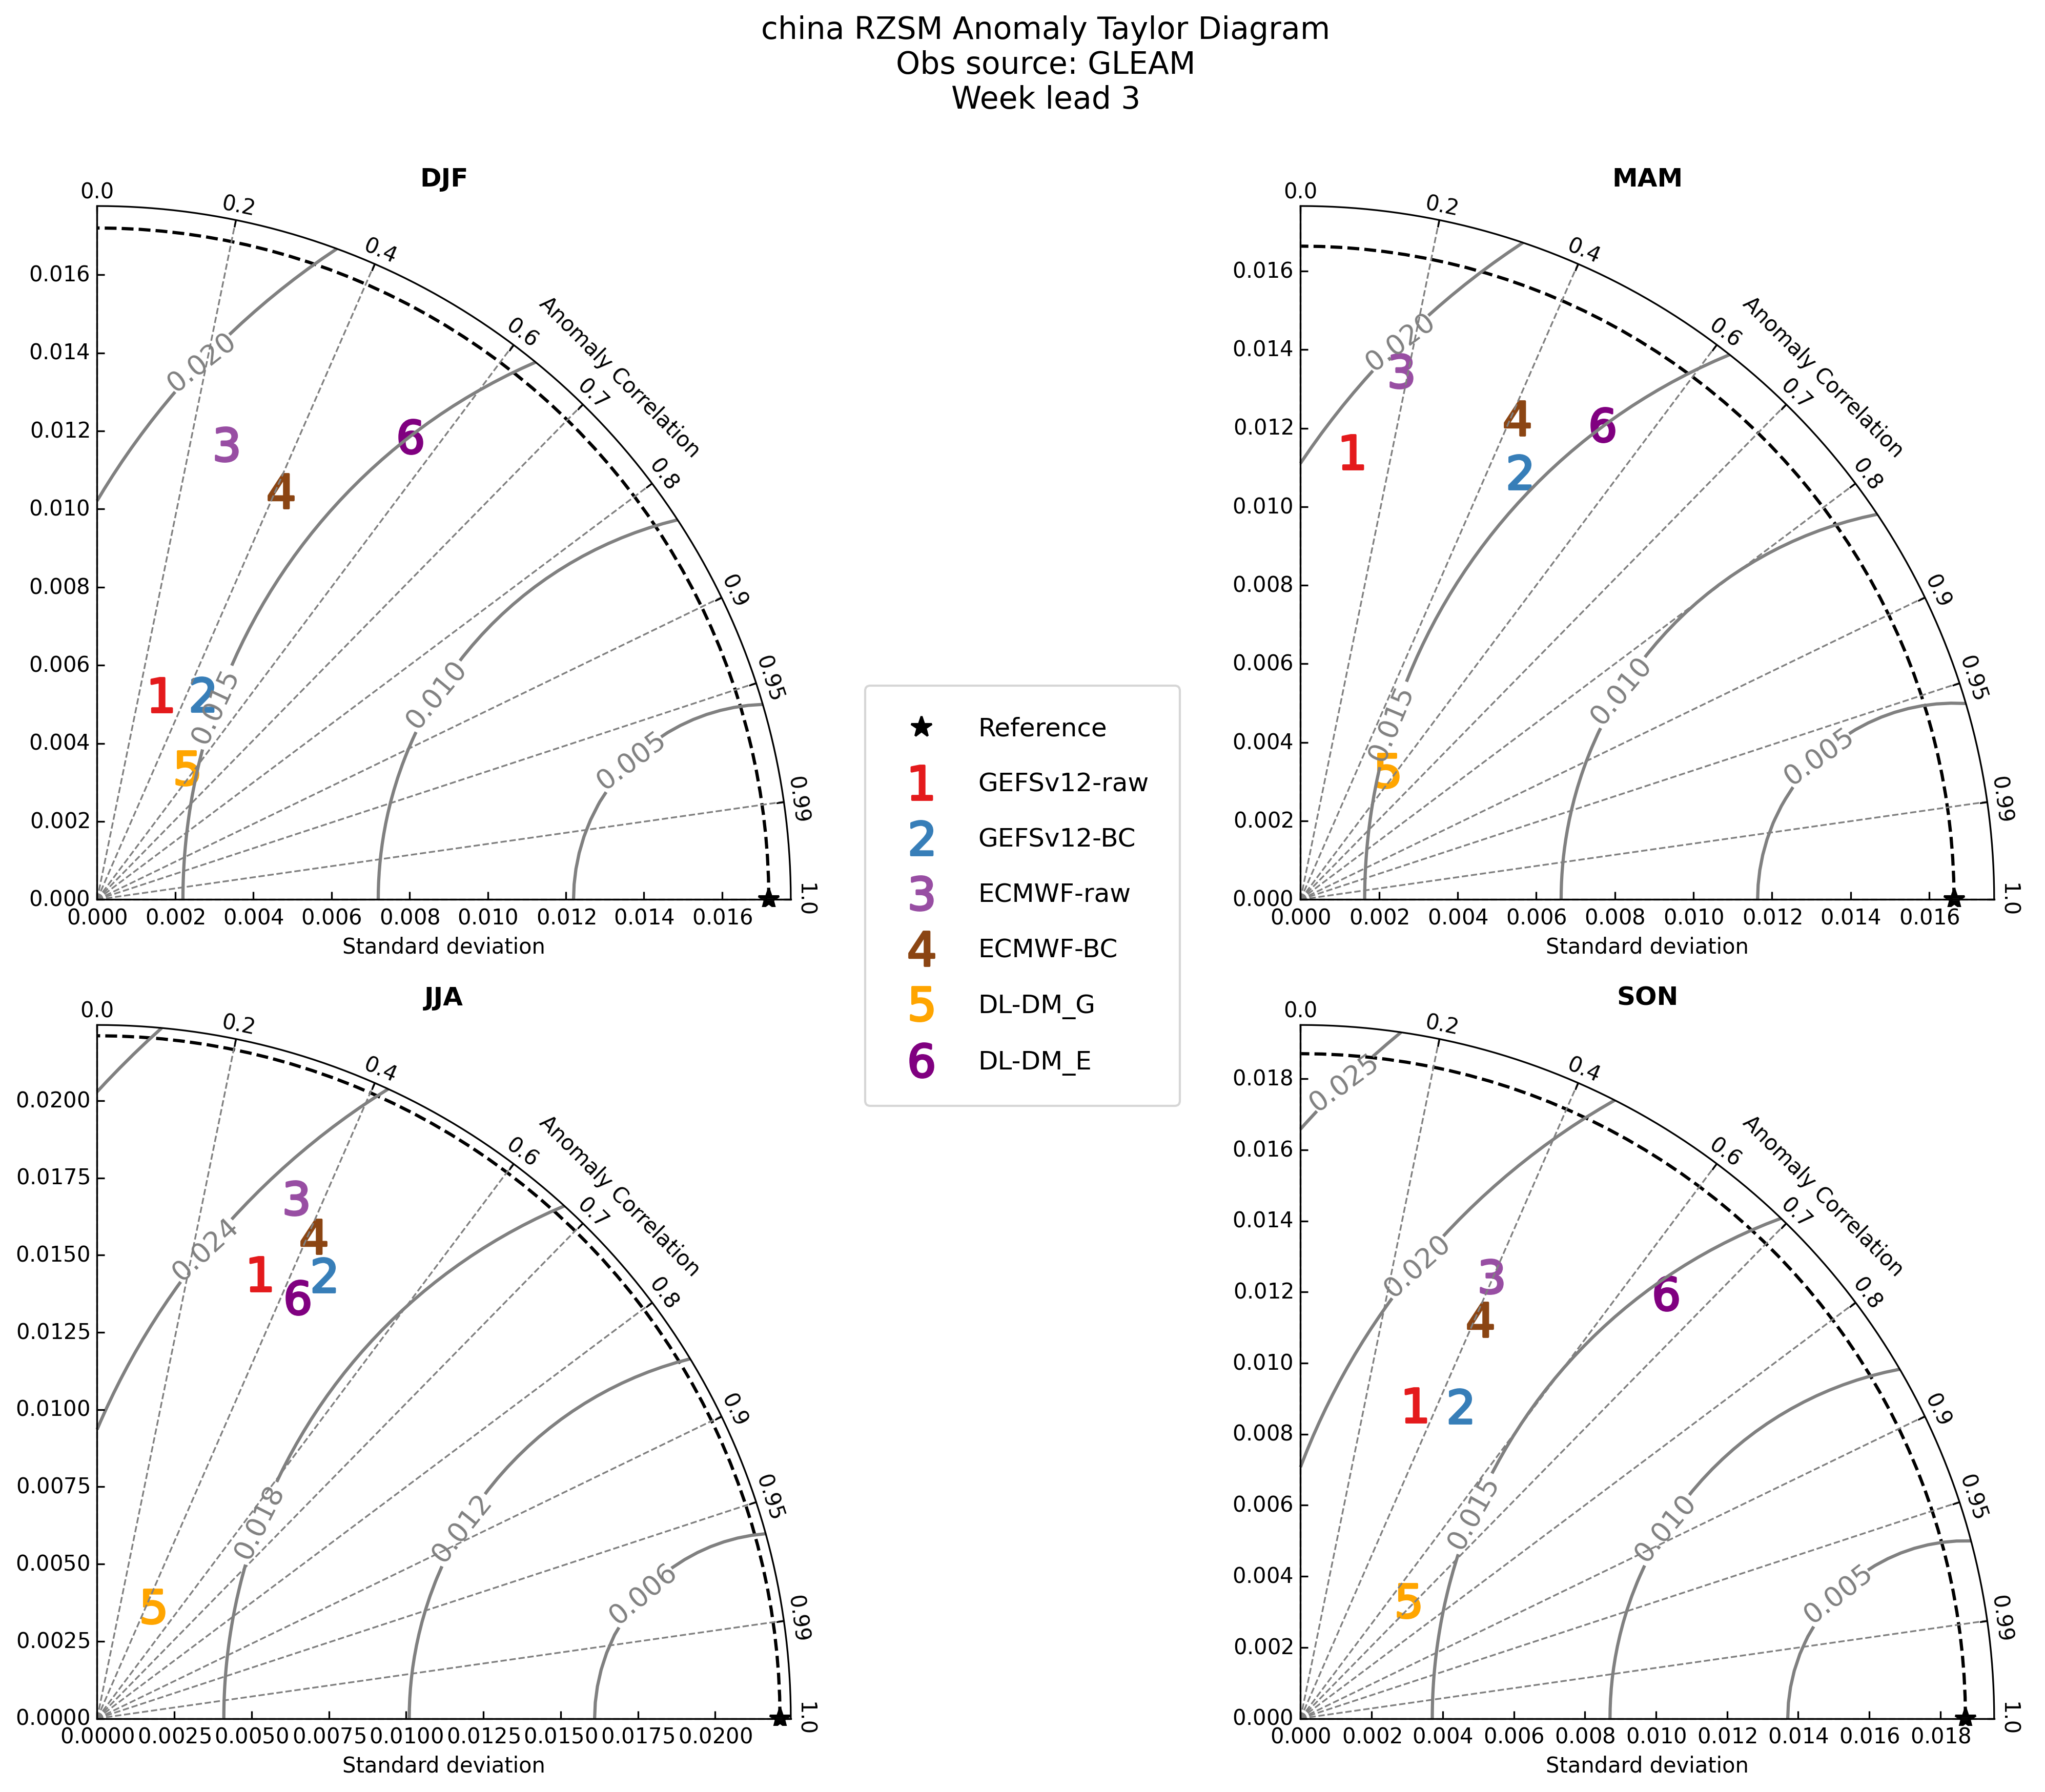

In [78]:


unet_ecmwf_std = get_UNET_std_forecast(region_name, obs_source, gef_BC, mask_anom,'ECMWF',day_num,experiment_number=experiment_number)
unet_gefsv12_std = get_UNET_std_forecast(region_name, obs_source, gef_BC, mask_anom,'GEFSv12',day_num,experiment_number=experiment_number)


#!/usr/bin/env python

__version__ = "Time-stamp: <2018-12-06 11:55:22 ycopin>"
__author__ = "Yannick Copin <yannick.copin@laposte.net>"

"""
Example of use of TaylorDiagram. Illustration dataset courtesy of Michael
Rawlins.

Rawlins, M. A., R. S. Bradley, H. F. Diaz, 2012. Assessment of regional climate
model simulation estimates over the Northeast United States, Journal of
Geophysical Research (2012JGRD..11723112R).
"""




# Colormap (see http://www.scipy.org/Cookbook/Matplotlib/Show_colormaps)
colors = PLT.matplotlib.cm.Set1(NP.linspace(0,1,len(samples['DJF'])))


rects = dict(DJF=221,
             MAM=222,
             JJA=223,
             SON=224)

fig = PLT.figure(figsize=(16, 12),dpi=300)

fig.suptitle(f"{region_name} RZSM Anomaly Taylor Diagram\nObs source: {obs_source}\nWeek lead {week_lead}", size='x-large', y=.97)

for season in ['DJF','MAM','JJA','SON']:
    std_models = [i[0] for i in samples[season]]
    max_std = np.nanmax(std_models)
    srange = (0, max_std / stdrefs[season] + 0.2)  # add a small buffer
    
    dia = TaylorDiagram(stdrefs[season], fig=fig, rect=rects[season],
                        label='Reference', srange=srange,)

    # dia.ax.plot(x95,y95,color='k')
    # dia.ax.plot(x99,y99,color='k')

    # Add samples to Taylor diagram
    for i,(stddev,corrcoef,name) in enumerate(samples[season]):
        color = colors[i]
        if i == 3:
            color = 'saddlebrown'  # or 'brown', '#8B4513', etc.
        elif i == 4:
            color = 'orange'
        elif i == 5:
            color = 'purple'
        dia.add_sample(stddev, corrcoef,
                       marker='$%d$' % (i+1), ms=16, ls='',
                       #mfc='k', mec='k', # B&W
                       mfc=color, mec=color, # Colors
                       label=name)

    # Add RMS contours, and label them
    contours = dia.add_contours(levels=5, colors='0.5') # 5 levels
    dia.ax.clabel(contours, inline=1, fontsize=13, fmt='%.3f')
    # Tricky: ax is the polar ax (used for plots), _ax is the
    # container (used for layout)
    dia._ax.set_title(season,fontweight='bold')
    dia.add_correlation_lines(linestyle='--', color='gray', linewidth=0.8)


# Add a figure legend and title. For loc option, place x,y tuple inside [ ].
# Can also use special options here:
# http://matplotlib.sourceforge.net/users/legend_guide.html

fig.legend(dia.samplePoints,
           [p.get_label() for p in dia.samplePoints],
           numpoints=1,
           prop={'size': 12},       # Increase font size
           loc='center',
           labelspacing=1.2,        # Vertical spacing between labels
           borderpad=1.2,           # Padding inside the legend box
           handletextpad=1.2,       # Space between marker and text
           columnspacing=1.5)       # Space between columns (if used)


fig.tight_layout(pad=2.5)

save_dir = f'Outputs/taylor_diagram'
os.makedirs(save_dir,exist_ok=True)

PLT.savefig(f'{save_dir}/{region_name}_{obs_source}_week{week_lead}_no_MSE.png')
PLT.show()


# test exapmle with random precipitation data

In [ ]:
class TaylorDiagram(object):
    """
    Taylor diagram.

    Plot model standard deviation and correlation to reference (data)
    sample in a single-quadrant polar plot, with r=stddev and
    theta=arccos(correlation).
    """

    def __init__(self, refstd,
                 fig=None, rect=111, label='_', srange=(0, 1.5), extend=False):
        """
        Set up Taylor diagram axes, i.e. single quadrant polar
        plot, using `mpl_toolkits.axisartist.floating_axes`.

        Parameters:

        * refstd: reference standard deviation to be compared to
        * fig: input Figure or None
        * rect: subplot definition
        * label: reference label
        * srange: stddev axis extension, in units of *refstd*
        * extend: extend diagram to negative correlations
        """

        from matplotlib.projections import PolarAxes
        import mpl_toolkits.axisartist.floating_axes as FA
        import mpl_toolkits.axisartist.grid_finder as GF

        self.refstd = refstd            # Reference standard deviation

        tr = PolarAxes.PolarTransform()

        # Correlation labels
        rlocs = NP.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1])
        if extend:
            # Diagram extended to negative correlations
            self.tmax = NP.pi
            rlocs = NP.concatenate((-rlocs[:0:-1], rlocs))
        else:
            # Diagram limited to positive correlations
            self.tmax = NP.pi/2
        tlocs = NP.arccos(rlocs)        # Conversion to polar angles
        gl1 = GF.FixedLocator(tlocs)    # Positions
        tf1 = GF.DictFormatter(dict(zip(tlocs, map(str, rlocs))))

        # Standard deviation axis extent (in units of reference stddev)
        self.smin = srange[0] * self.refstd
        self.smax = srange[1] * self.refstd

        ghelper = FA.GridHelperCurveLinear(
            tr,
            extremes=(0, self.tmax, self.smin, self.smax),
            grid_locator1=gl1, tick_formatter1=tf1)

        if fig is None:
            fig = PLT.figure()

        ax = FA.FloatingSubplot(fig, rect, grid_helper=ghelper)
        fig.add_subplot(ax)

        # Adjust axes
        ax.axis["top"].set_axis_direction("bottom")   # "Angle axis"
        ax.axis["top"].toggle(ticklabels=True, label=True)
        ax.axis["top"].major_ticklabels.set_axis_direction("top")
        ax.axis["top"].label.set_axis_direction("top")
        ax.axis["top"].label.set_text("Correlation")

        ax.axis["left"].set_axis_direction("bottom")  # "X axis"
        ax.axis["left"].label.set_text("Standard deviation")

        ax.axis["right"].set_axis_direction("top")    # "Y-axis"
        ax.axis["right"].toggle(ticklabels=True)
        ax.axis["right"].major_ticklabels.set_axis_direction(
            "bottom" if extend else "left")

        if self.smin:
            ax.axis["bottom"].toggle(ticklabels=False, label=False)
        else:
            ax.axis["bottom"].set_visible(False)          # Unused

        self._ax = ax                   # Graphical axes
        self.ax = ax.get_aux_axes(tr)   # Polar coordinates

        # Add reference point and stddev contour
        l, = self.ax.plot([0], self.refstd, 'k*',
                          ls='', ms=10, label=label)
        t = NP.linspace(0, self.tmax)
        r = NP.zeros_like(t) + self.refstd
        self.ax.plot(t, r, 'k--', label='_')

        # Collect sample points for latter use (e.g. legend)
        self.samplePoints = [l]

    def add_sample(self, stddev, corrcoef, *args, **kwargs):
        """
        Add sample (*stddev*, *corrcoeff*) to the Taylor
        diagram. *args* and *kwargs* are directly propagated to the
        `Figure.plot` command.
        """

        l, = self.ax.plot(NP.arccos(corrcoef), stddev,
                          *args, **kwargs)  # (theta, radius)
        self.samplePoints.append(l)

        return l

    def add_grid(self, *args, **kwargs):
        """Add a grid."""

        self._ax.grid(*args, **kwargs)

    def add_contours(self, levels=5, **kwargs):
        """
        Add constant centered RMS difference contours, defined by *levels*.
        """

        rs, ts = NP.meshgrid(NP.linspace(self.smin, self.smax),
                             NP.linspace(0, self.tmax))
        # Compute centered RMS difference
        rms = NP.sqrt(self.refstd**2 + rs**2 - 2*self.refstd*rs*NP.cos(ts))

        contours = self.ax.contour(ts, rs, rms, levels, **kwargs)

        return contours